# Model Tester

In [19]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
import os
import sys
import math
import logging
import healpy as hp
import numpy as np

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import tensorflow as tf

from tensorflow.keras.layers import (  # type: ignore
    Dense,
    Dropout,
    Flatten,
    LeakyReLU,
    Permute,
)
from tensorflow.keras.callbacks import (  # type: ignore
    EarlyStopping,
    TerminateOnNaN,
    TensorBoard,
    ModelCheckpoint,
)
from tensorflow.keras.optimizers import Adam, AdamW  # type: ignore
from tensorflow.keras.optimizers.schedules import ExponentialDecay  # type: ignore
from tensorflow.keras.metrics import RootMeanSquaredError  # type: ignore
from tensorflow.data.experimental import assert_cardinality

from mlpng import Core
from mlpng.utils import (
    setup_logging,
    plot_predictions,
    plot_histogram,
    print_errors,
    plot_metrics,
    try_init_wandb,
)

from deepsphere import HealpyGCNN
from deepsphere.healpy_layers import (
    HealpyChebyshev,
    HealpyPool,
)

keras = tf.keras

logger = setup_logging(__name__, level=logging.DEBUG)

In [21]:
print("Conda environment:", os.environ["CONDA_DEFAULT_ENV"])
print("Python executable:", sys.executable)
print(f"TensorFlow version: {tf.__version__}")
print(f"CUDA version: {tf.sysconfig.get_build_info()['cuda_version']}")
print(f"cuDNN version: {tf.sysconfig.get_build_info()['cudnn_version']}")

Conda environment: ds25
Python executable: /users/stevensonb/.conda/envs/ds25/bin/python
TensorFlow version: 2.16.2
CUDA version: 12.3
cuDNN version: 8


In [22]:
import h5py
from itertools import product


class ALMDataset:

    file_path: str
    duplicates: int
    x_shape: tuple[int, ...]
    y_shape: tuple[int, ...]
    start_idx: int
    end_idx: int
    shapes: list[str]
    l_str: str

    @classmethod
    def fromCore(
        cls,
        core,
        shapes=["all"],
        start_idx=0,
        end_idx: int | None = None,
        lensed=False,
    ):
        return cls(
            file_path=core.file,
            x_shape=core.alm_shape[2:],
            duplicates=core.ndups,
            shapes=shapes,
            start_idx=start_idx,
            end_idx=end_idx,
            lensed=lensed,
            fnl_min=core.fnl_min,
            fnl_max=core.fnl_max,
        )

    def __init__(
        self,
        file_path,
        x_shape,
        duplicates=10,
        shapes=None,
        start_idx=0,
        end_idx: int | None = None,
        lensed=False,
        seed=None,
        x_dtype=tf.float32,
        y_dtype=tf.float32,
        fnl_min=-1000.0,
        fnl_max=1000.0,
    ):
        # setup shapes
        if isinstance(shapes, str):
            shapes = [shapes]
        if shapes is None or "all" in shapes:
            shapes = ["local", "equilateral", "orthogonal"]

        self.shapes = shapes
        self.y_shape = (len(shapes),)
        self.duplicates = duplicates
        self.l_str = "lensed" if lensed else "unlensed"
        self.file_path = file_path
        self.start_idx = start_idx
        self.x_shape = x_shape
        self.x_dtype = x_dtype
        self.y_dtype = y_dtype
        self.fnl_min = fnl_min
        self.fnl_max = fnl_max
        if end_idx is None:
            with h5py.File(self.file_path, mode="r", swmr=True, locking=False) as f:
                self.end_idx = f["alm_l"].shape[0]
        else:
            self.end_idx = end_idx
        self.rng = np.random.default_rng(seed)

    def __len__(self):
        return self.end_idx - self.start_idx

    def _get(self, sim, dup):
        with h5py.File(self.file_path, mode="r", swmr=True, locking=False) as f:
            x = f["alm_l"][sim]
            y = self.rng.uniform(
                low=self.fnl_min,
                high=self.fnl_max,
                size=len(self.shapes),
            )

            for i, shape in enumerate(self.shapes):
                alm_nl = f[self.l_str][shape]["alm_nl"][sim]
                x = x + y[i, None] * alm_nl
        return x, y

    def _load(self, i):
        x, y = tf.py_function(
            func=self._get,
            inp=[i[0], i[1]],
            Tout=(self.x_dtype, self.y_dtype),
            name="py_loader",
        )  # type: ignore
        x.set_shape(self.x_shape)
        y.set_shape(self.y_shape)
        return x, y

    def split(
        self,
        train_size=0.8,
        val_size=0.1,
        test_size=0.1,
        to_tf=True,
        batch_size=32,
    ):
        # split the data into train, val, test
        n = self.end_idx - self.start_idx
        train_end = self.start_idx + int(n * train_size)
        val_end = train_end + int(n * val_size)
        test_end = np.min((val_end + int(n * test_size), self.end_idx))

        cls = self.__class__  # so we dont have to change this if we subclass
        kwargs = {
            "file_path": self.file_path,
            "duplicates": self.duplicates,
            "x_shape": self.x_shape,
            "x_dtype": self.x_dtype,
            "y_dtype": self.y_dtype,
            "shapes": self.shapes,
            "lensed": "lensed" in self.l_str,
            "fnl_min": self.fnl_min,
            "fnl_max": self.fnl_max,
        }
        train = cls(**kwargs, start_idx=self.start_idx, end_idx=train_end)
        val = cls(**kwargs, start_idx=train_end, end_idx=val_end)
        test = cls(**kwargs, start_idx=val_end, end_idx=test_end)

        if to_tf:
            train = train.to_tf(batch_size, True)
            val = val.to_tf(batch_size, True)
            test = test.to_tf(batch_size, False)
        return train, val, test

    def to_tf(self, batch_size=32, reshuffle=True):
        indices = list(
            product(range(self.start_idx, self.end_idx), range(self.duplicates))
        )

        ds = tf.data.Dataset.from_generator(
            lambda: indices,
            output_signature=tf.TensorSpec(shape=(2,), dtype=tf.int32),
            name="index_generator",
        )

        ds = ds.map(
            self._load,
            num_parallel_calls=tf.data.AUTOTUNE,
            deterministic=False,
            name="data_loader",
        )

        ds = ds.apply(assert_cardinality(len(indices)))
        ds = ds.cache()
        ds = ds.shuffle(
            buffer_size=min(1024, len(indices)), reshuffle_each_iteration=reshuffle
        )
        ds = ds.batch(
            batch_size,
            # drop_remainder=True,
            num_parallel_calls=tf.data.AUTOTUNE,
            deterministic=False,
            name="batcher",
        )
        return ds.prefetch(tf.data.AUTOTUNE)

    def get_fisher(self, shape, lensed=False):
        with h5py.File(self.file_path, mode="r", swmr=True, locking=False) as f:
            fisher = f[self.l_str][shape]["fisher"][0]
        return fisher

In [ ]:
class MapDataset(ALMDataset):
    @classmethod
    def fromCore(
        cls,
        core,
        shapes=None,
        start_idx=0,
        end_idx: int | None = None,
        lensed=False,
    ):
        return cls(
            file_path=core.file,
            duplicates=core.ndups,
            x_shape=(core.npix, core.npols),
            x_dtype=core.r_dtype,
            y_dtype=core.r_dtype,
            shapes=shapes,
            start_idx=start_idx,
            end_idx=end_idx,
            lensed=lensed,
            nside=core.nside,
            fnl_min=core.fnl_min,
            fnl_max=core.fnl_max,
        )

    def __init__(
        self,
        file_path,
        x_shape,
        duplicates=25,
        x_dtype=tf.complex64,
        y_dtype=tf.float32,
        shapes=None,
        start_idx=0,
        end_idx: int | None = None,
        lensed=False,
        nside=32,
        fnl_min=-1000.0,
        fnl_max=1000.0,
    ):
        super().__init__(
            file_path=file_path,
            x_shape=x_shape,
            duplicates=duplicates,
            shapes=shapes,
            start_idx=start_idx,
            end_idx=end_idx,
            lensed=lensed,
            x_dtype=x_dtype,
            y_dtype=y_dtype,
            fnl_min=fnl_min,
            fnl_max=fnl_max,
        )
        self.nside = nside

    def _get(self, sim, dup):
        x, y = super()._get(sim, dup)

        maps = []
        for i in range(x.shape[0]):
            maps.append(hp.alm2map(x[i].astype(complex), nside=self.nside, pol=False))
        maps = np.transpose(maps, (1, 0))
        return maps, y

In [24]:
class LinearWarmup(tf.keras.optimizers.schedules.LearningRateSchedule):
    """Linear warmup schedule."""

    def __init__(
        self,
        after_warmup_lr_sched: (
            tf.keras.optimizers.schedules.LearningRateSchedule | float
        ),
        warmup_steps: int,
        warmup_learning_rate: float,
        name: str | None = None,
    ):
        """Add linear warmup schedule to a learning rate schedule.

        warmup_lr is the initial learning rate, the final learning rate of the
        init_warmup period is the initial learning rate of lr_schedule in use.
        The learning rate at each step linearly increased according to the following
        formula:
          learning_rate = warmup_lr + step / warmup_steps
                        * (final_warmup_lr - warmup_lr).
        Using warmup overrides the learning rate schedule by the number of warmup
        steps.

        Args:
          after_warmup_lr_sched: tf.keras.optimizers.schedules .LearningRateSchedule
            or a constant.
          warmup_steps: Number of the warmup steps.
          warmup_learning_rate: Initial learning rate for the warmup.
          name: Optional, name of warmup schedule.
        """
        super().__init__()
        self._name = name
        self._after_warmup_lr_sched = after_warmup_lr_sched
        self._warmup_steps = warmup_steps
        self._init_warmup_lr = warmup_learning_rate
        if isinstance(
            after_warmup_lr_sched, tf.keras.optimizers.schedules.LearningRateSchedule
        ):
            self._final_warmup_lr = after_warmup_lr_sched(warmup_steps)
        else:
            self._final_warmup_lr = tf.cast(after_warmup_lr_sched, dtype=tf.float32)

    def __call__(self, step: int):

        global_step = tf.cast(step, dtype=tf.float32)
        # print("Global step", global_step, flush=True)

        linear_warmup_lr = self._init_warmup_lr + global_step / self._warmup_steps * (
            self._final_warmup_lr - self._init_warmup_lr
        )

        if isinstance(
            self._after_warmup_lr_sched,
            tf.keras.optimizers.schedules.LearningRateSchedule,
        ):
            after_warmup_lr = self._after_warmup_lr_sched(step)
        else:
            after_warmup_lr = tf.cast(self._after_warmup_lr_sched, dtype=tf.float32)

        lr = tf.cond(
            global_step < self._warmup_steps,
            lambda: linear_warmup_lr,
            lambda: after_warmup_lr,
        )
        return lr

    def get_config(self):
        if isinstance(
            self._after_warmup_lr_sched,
            tf.keras.optimizers.schedules.LearningRateSchedule,
        ):
            config = {
                "after_warmup_lr_sched": self._after_warmup_lr_sched.get_config()
            }  # pytype: disable=attribute-error
        else:
            config = {
                "after_warmup_lr_sched": self._after_warmup_lr_sched
            }  # pytype: disable=attribute-error

        config.update(
            {
                "warmup_steps": self._warmup_steps,
                "warmup_learning_rate": self._init_warmup_lr,
                "name": self._name,
            }
        )
        return config

In [25]:
max_epochs = 100
batch_size = 32


def get_model(input_shape, n_y=3):
    nside = hp.npix2nside(input_shape[1])
    indices = np.arange(input_shape[1])
    layers = []

    n_layers = math.floor(math.log(nside, 2))
    for i in range(n_layers):
        fout = 2 ** (4 + i)
        layers.append(
            HealpyChebyshev(
                K=2,
                Fout=fout,
                use_bias=True,
                use_bn=True,
                activation=LeakyReLU(0.3),
            )
        )
        layers.append(Dropout(0.1))
        layers.append(HealpyPool(1, "AVG"))

    layers.append(Flatten())
    layers.append(Dropout(0.3))
    layers.append(Dense(32, activation=LeakyReLU(0.3)))
    layers.append(Dense(32, activation=LeakyReLU(0.3)))
    layers.append(Dense(n_y))

    model = HealpyGCNN(
        nside,
        indices=indices,
        layers=layers,
        max_batch_size=batch_size,
        initial_Fin=input_shape[-1],
        n_neighbors=8,
    )

    model.build(input_shape)
    return model

In [26]:
core = Core(
    [
        "settings/n32.json",
        "--nsims",
        "1000",
        # "--fnl_range",
        # "-100",
        # "100",
        # "--pols",
        # "T",
    ]
)

25-Feb-25 17:39:54 - mlpng.core - DEBUG - Parsing CLI args: ['settings/n32.json', '--nsims', '1000']
25-Feb-25 17:39:54 - mlpng.core - INFO - Loading settings from file 'settings/n32.json'
25-Feb-25 17:39:54 - mlpng.core - DEBUG - Forcing setting 'nsims' to 1000 due to CLI
25-Feb-25 17:39:54 - mlpng.core - DEBUG - Overriding cosmo param 'As' from 2.13e-09 to 2.457e-09
25-Feb-25 17:39:54 - mlpng.core - DEBUG - Overriding cosmo param 'ns' from 0.9624 to 0.9649
25-Feb-25 17:39:54 - mlpng.core - DEBUG - Running with settings: 
{
  "cosmo_params": {
    "As": 2.457e-09,
    "ns": 0.9649,
    "pivot_scalar": 0.05,
    "H0": 67.4,
    "ombh2": 0.0224,
    "omch2": 0.12,
    "tau": 0.054
  },
  "nsims": 1000,
  "nside": 32
}
25-Feb-25 17:39:54 - mlpng.core - DEBUG - Found non-default value for 'nside': 32 (default: 128)
25-Feb-25 17:39:54 - mlpng.core - DEBUG - Found non-default value for 'nsims': 1000 (default: 100)
25-Feb-25 17:39:54 - mlpng.core - WARNING - Forcing isotropic mode


In [27]:
shapes = ["local"]  # , "equilateral", "orthogonal"]
ds = MapDataset.fromCore(core, shapes=shapes, lensed=False)

train, val, test = ds.split(batch_size=batch_size)
decay_steps = len(train)

strategy = tf.distribute.MirroredStrategy()
with strategy.scope():
    learning_rate = ExponentialDecay(1e-5, decay_steps, 0.98, staircase=True)
    learning_rate = LinearWarmup(learning_rate, decay_steps * 5, 1e-8)

    model = get_model((batch_size, core.npix, core.npols), n_y=len(shapes))
    model.compile(
        optimizer=AdamW(learning_rate),  # , weight_decay=0.1),  # type: ignore
        loss="mse",
        metrics=[RootMeanSquaredError()],  # type: ignore
    )

model.summary()

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0',)
25-Feb-25 17:39:56 - tensorflow - INFO - Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0',)


Model: "healpy_gcnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ chebyshev (Chebyshev)           │ (32, 12288, 16)        │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (32, 12288, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ healpy_pool (HealpyPool)        │ (32, 3072, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ chebyshev_1 (Chebyshev)         │ (32, 3072, 32)         │         1,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (32, 3072, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ healpy_pool_1 (HealpyPool)      │ (32, 768, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ chebyshev_2 (Chebyshev)         │ (32, 768, 64)          │         4,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (32, 768, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ healpy_pool_2 (HealpyPool)      │ (32, 192, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ chebyshev_3 (Chebyshev)         │ (32, 192, 128)         │        16,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (32, 192, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ healpy_pool_3 (HealpyPool)      │ (32, 48, 128)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ chebyshev_4 (Chebyshev)         │ (32, 48, 256)          │        66,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (32, 48, 256)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ healpy_pool_4 (HealpyPool)      │ (32, 12, 256)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (32, 3072)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (32, 3072)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (32, 32)               │        98,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 32)               │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (32, 1)                │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 187,985 (734.32 KB)

 Trainable params: 186,993 (730.44 KB)

 Non-trainable params: 992 (3.88 KB)

In [28]:
callbacks = [
    TerminateOnNaN(),
    EarlyStopping(monitor="val_loss", patience=16, restore_best_weights=True),
]
if core.use_tb:
    callbacks.append(
        TensorBoard(
            log_dir=core.dirs["tb"],
        )
    )
if core.use_wandb:
    try_init_wandb(
        config={
            "batch_size": batch_size,
            "max_epochs": max_epochs,
            # "learning_rate": 5e-3,
        },
        dir=core.dirs["data"],
        append_to=callbacks,
        patch_tb=core.use_tb,
    )

history = model.fit(
    train,
    epochs=max_epochs,
    validation_data=val,
    callbacks=callbacks,
    verbose=1,
)
# model.save(f"{core.dirs['model']}/{core.name}-{core.slurm.job}-jorik.keras")

Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 286s 426ms/step - loss: 331654.0625 - root_mean_squared_error: 575.8381 - val_loss: 327770.9375 - val_root_mean_squared_error: 572.5128
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 333560.3438 - root_mean_squared_error: 577.5390 - val_loss: 327209.0000 - val_root_mean_squared_error: 572.0219
Epoch 3/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 331322.9688 - root_mean_squared_error: 575.5830 - val_loss: 322789.4375 - val_root_mean_squared_error: 568.1456
Epoch 4/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 323873.8125 - root_mean_squared_error: 569.0926 - val_loss: 299691.0625 - val_root_mean_squared_error: 547.4404
Epoch 5/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 291318.6250 - root_mean_squared_error: 539.6789 - val_loss: 238456.4688 - val_root_mean_squared_error: 488.3200
Epoch 6/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 226440.2031 - root_mean_squared_error: 475.7242 - val_loss: 15985

In [29]:
logger.debug("Getting final plots")
y = np.concatenate([y for _, y in test])  # type: ignore
preds = model.predict(test, verbose=0)
# using evaluate to get the rmse since manually calculating it was giving a different value
rmse = model.evaluate(test, verbose=0)[1]

25-Feb-25 17:47:36 - __main__ - DEBUG - Getting final plots


25-Feb-25 17:48:18 - mlpng.utils.utils - INFO - Standard deviation from fisher: 84.51150663003772, SEM: 1.6902301326007543
25-Feb-25 17:48:18 - mlpng.utils.utils - INFO - Mean error: 136.36034, Median error: 134.27264
25-Feb-25 17:48:18 - mlpng.utils.utils - INFO - 19.88% (19.56, 20.24) are within 1 standard deviations
25-Feb-25 17:48:18 - mlpng.utils.utils - INFO - 36.44% (35.839999999999996, 37.04) are within 2 standard deviations
25-Feb-25 17:48:18 - mlpng.utils.utils - INFO - 50.760000000000005% (50.03999999999999, 51.44) are within 3 standard deviations
25-Feb-25 17:48:18 - mlpng.utils.utils - INFO - 61.919999999999995% (61.12, 62.88) are within 4 standard deviations
25-Feb-25 17:48:18 - mlpng.utils.utils - INFO - 71.16% (70.39999999999999, 71.64) are within 5 standard deviations


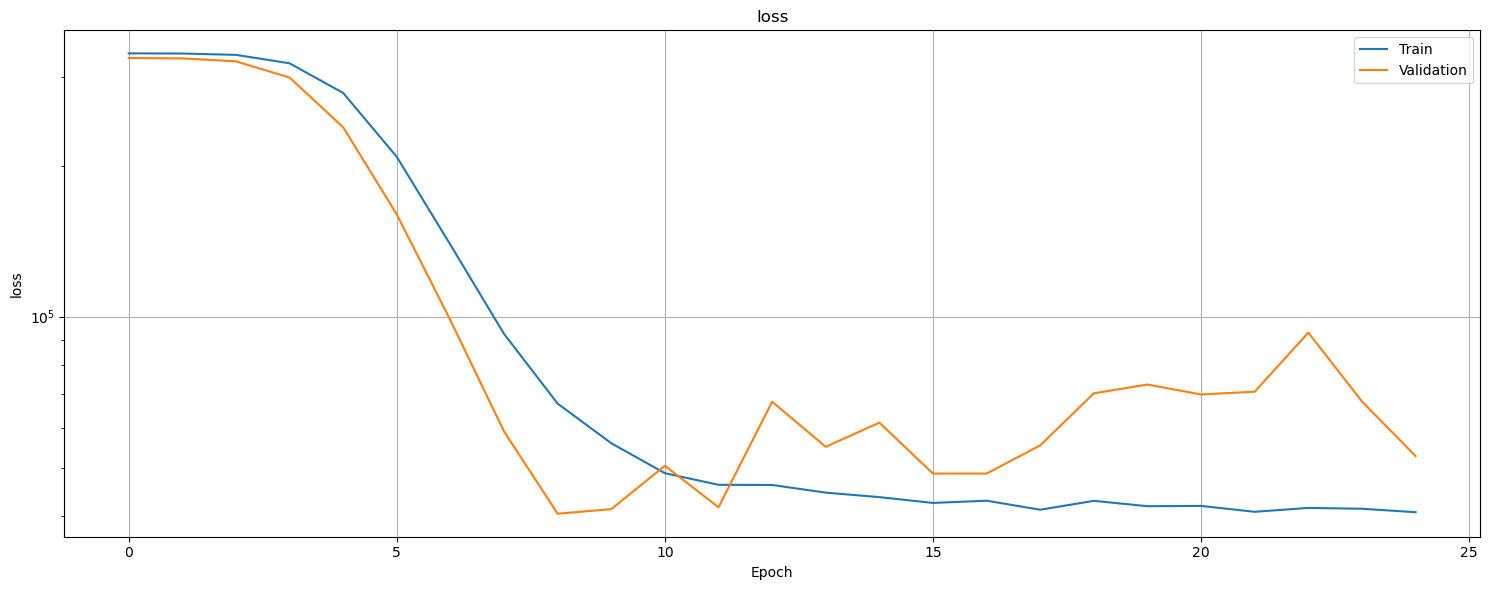

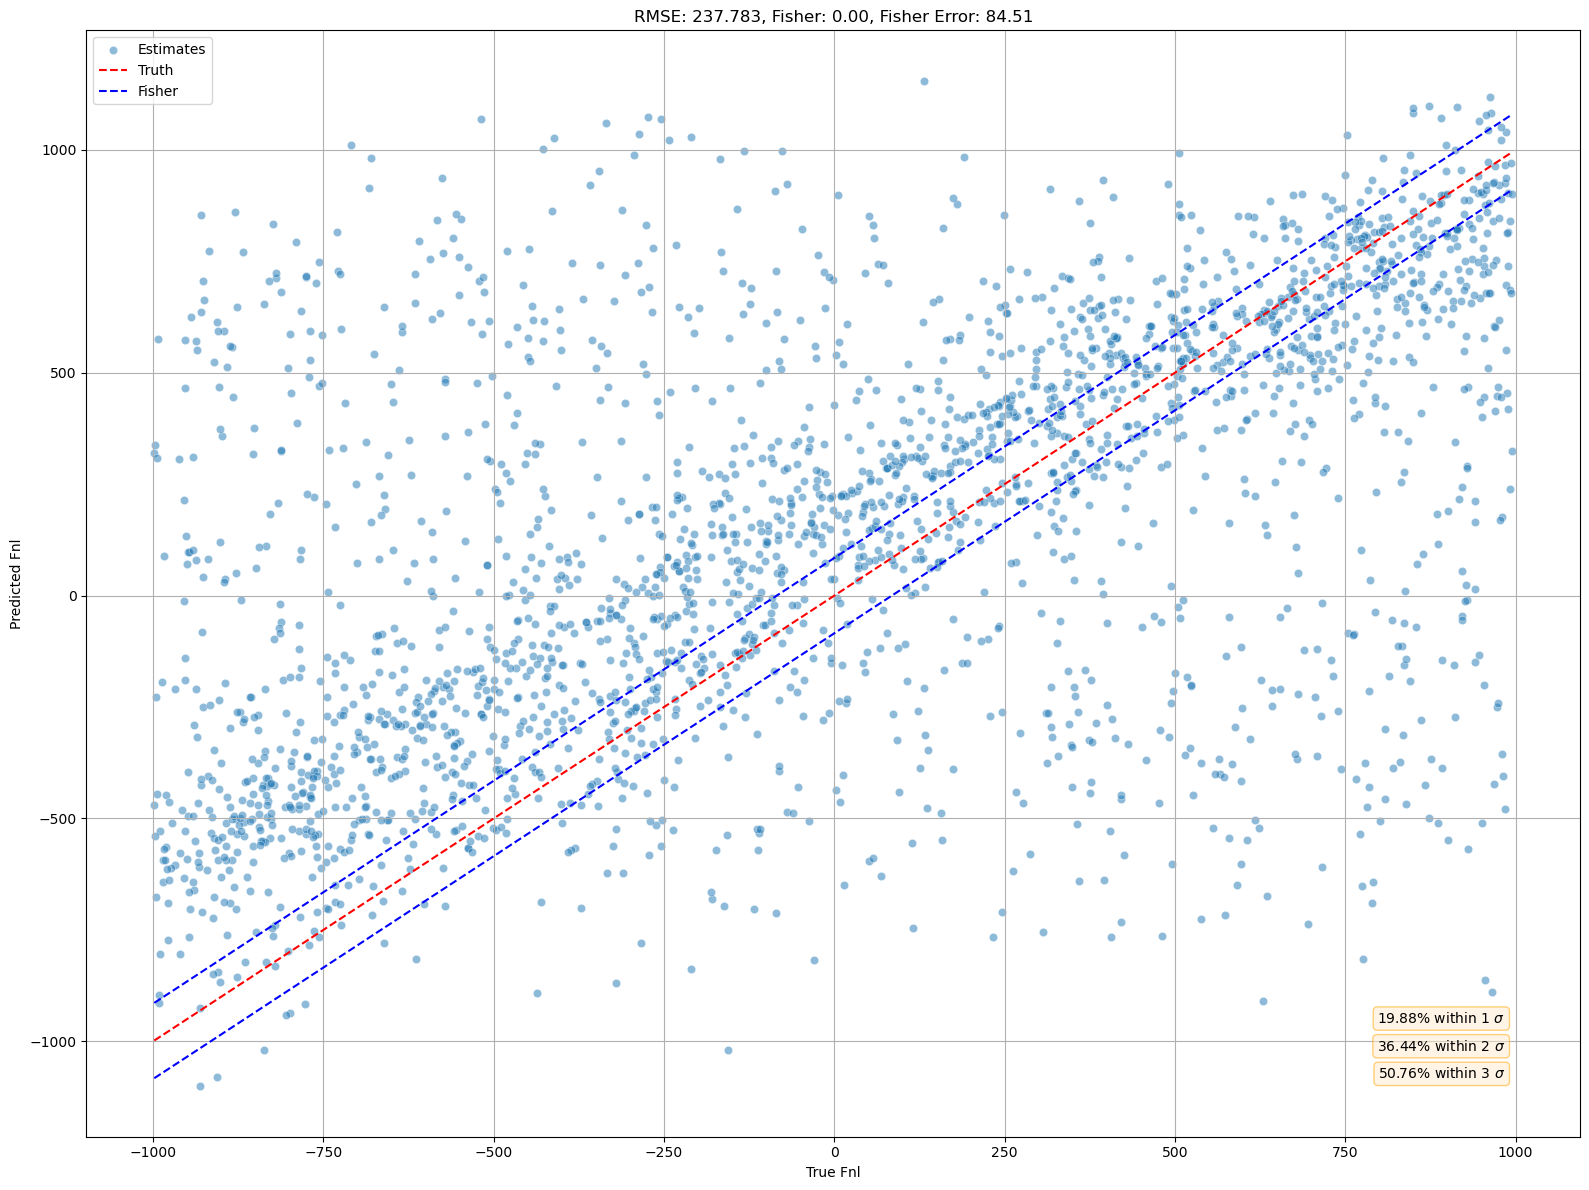

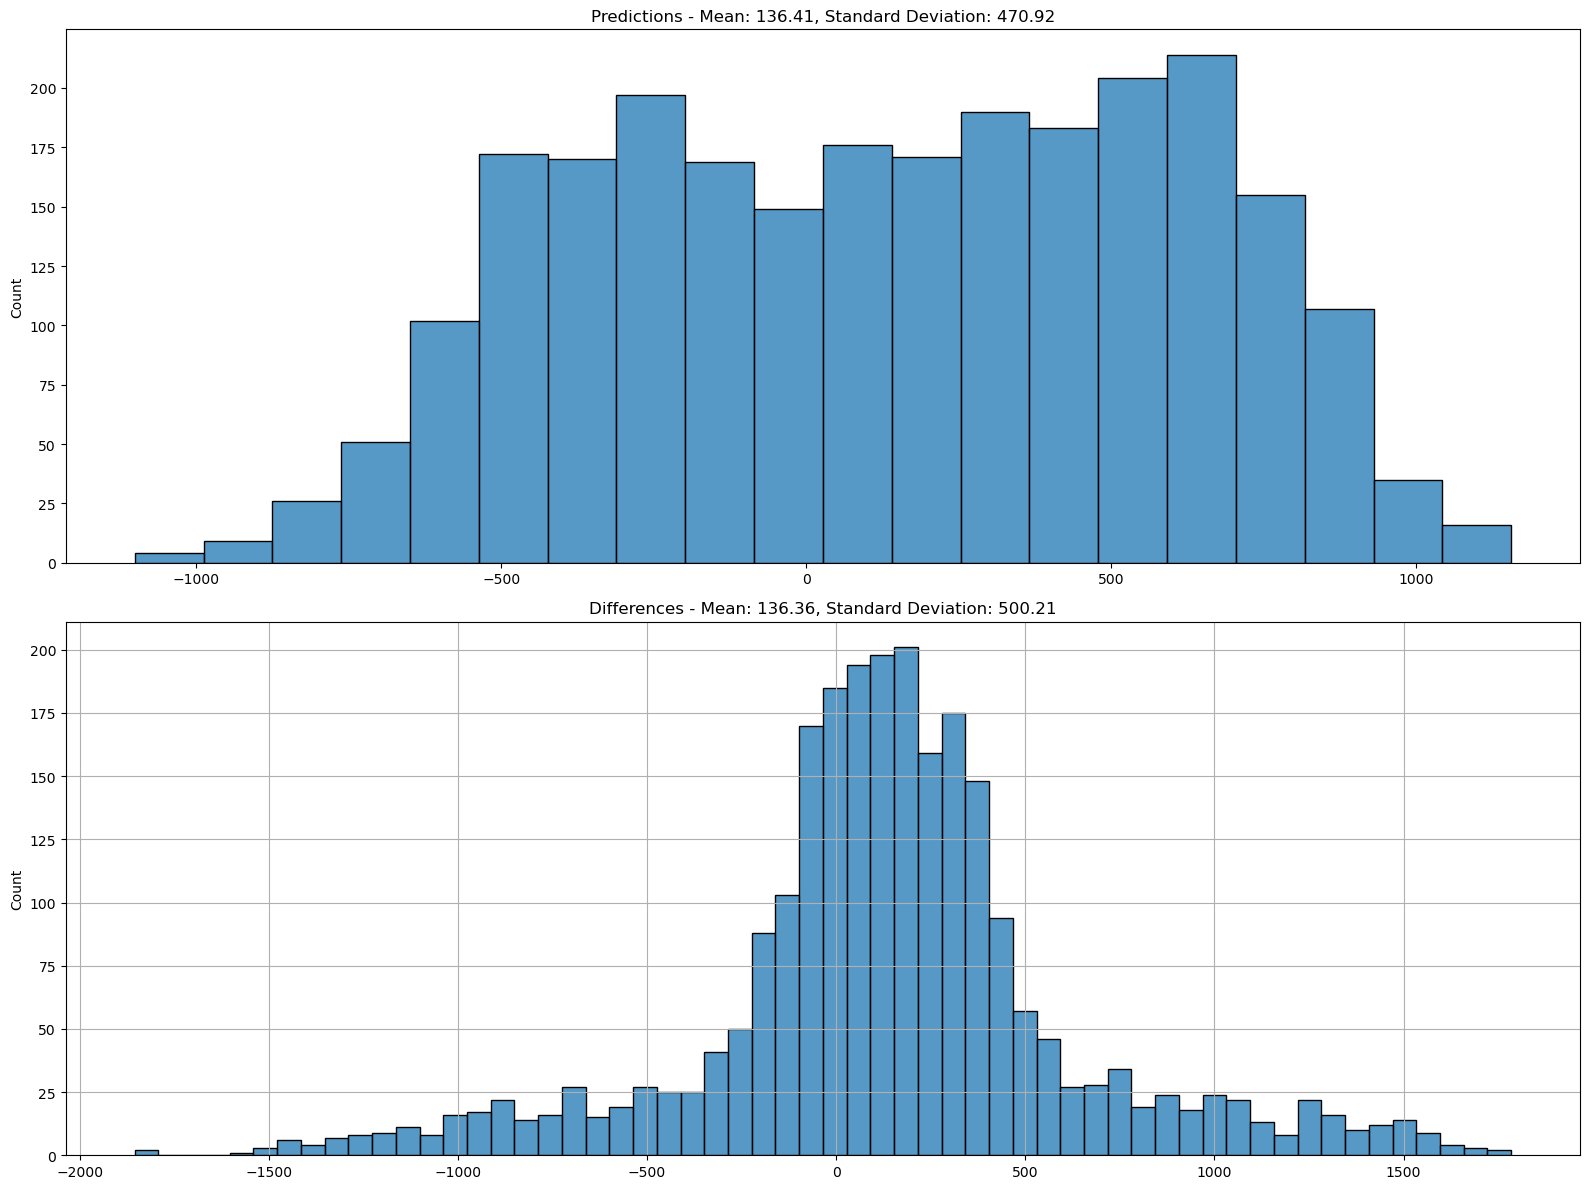

In [30]:
fisher = ds.get_fisher("local")

print_errors(y, preds, fisher)
plot_metrics(history, metrics=["loss"], show=True)

for shape in range(y.shape[1]):
    plot_predictions(
        y[:, shape],
        preds[:, shape],
        fisher=fisher,
        title=f"RMSE: {rmse:.3f}",
        show=True,
    )
    plot_histogram(y[:, shape], preds[:, shape], show=True)